# AI2Analytics Quickstart

The smallest end-to-end example: synthetic HCP data → segmentation → cluster
profiles → 2-D plot. Five cells, runs anywhere with a Python kernel.

> Install once per session (the next cell is safe to re-run).

In [1]:
# Run once per session. In Colab, this installs into the runtime;
# in local Jupyter, it goes to the active kernel's environment.
import sys, subprocess
def _ensure(pkg, import_name=None):
    name = import_name or pkg.split('[')[0].split('==')[0]
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# In Colab/Jupyter, install ai2analytics from GitHub. If it's already
# installed locally (editable), this is a no-op.
try:
    import ai2analytics  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'git+https://github.com/jamesyoung93/AI2Analytics.git'])

# Plot helpers (matplotlib is already a hard dep of ai2analytics)
_ensure('matplotlib')
print('Setup complete.')

Setup complete.


## 1. Generate synthetic HCP data

5,000 fake providers with two prescribing-volume features. Bundled with the
package, so no file downloads or git checkouts.

In [2]:
from ai2analytics.datasets import us_hcp
tables = us_hcp.generate_all()
hcps = tables['hcp_reference']
hcps.head()

Generating synthetic US HCP data (seed=42) ...
  hcp_reference:        5,000 rows


  hcp_weekly:         114,011 rows


  calls:               32,726 rows
  team_a_alignment:     4,255 rows
  team_b_alignment:     3,964 rows
  portfolio_decile:     5,000 rows
  priority_targets:       500 rows
Done.



,npi,WRITER_FLAG,TARGET_FLAG,IL_17_TRX_L12M,IL_23_TRX_L12M
0,1004668697,Y,N,29,23
1,1005113163,N,N,2,4
2,1005780733,N,Y,0,0
3,1007421551,Y,Y,12,2
4,1008334960,Y,Y,4,6


## 2. Run the segmentation pipeline

`SegmentationPipeline` is the same class used for every region/brand —
configuration tells it which entity ID and which numeric features to cluster on.

In [3]:
from ai2analytics.templates.segmentation import SegmentationConfig, SegmentationPipeline

cfg = SegmentationConfig(
    analysis_name='quickstart',
    col_entity_id='npi',
    feature_columns=['IL_17_TRX_L12M', 'IL_23_TRX_L12M'],
    n_segments=4,
    method='kmeans',
    output_csv='quickstart_segments.csv',
)
out = SegmentationPipeline().run(cfg, dataframes={'entity_data': hcps})


  PIPELINE: quickstart Segmentation

STAGE 1: Loading data
  Entity data:  5,000 rows (in-memory)
  Feature cols: 2 specified
  Done.

STAGE 2: Preparing features
  Missing handling: filled with column median
  Feature matrix:   5,000 entities x 2 features
  Normalization:    standard
  Done.

STAGE 3: Fitting segments
  Method: kmeans


  Segments:     4
  Silhouette:   0.6142
  Done.

STAGE 4: Building output
  Assignments:  5,000 entities
  Profiles:     4 segments x 2 features
  Done.

STAGE 5: Writing output
  CSV:   quickstart_segments.csv (5,000 rows)
  Done.


PIPELINE COMPLETE
  Analysis:     quickstart
  Entities:     5,000
  Segments:     4
  Method:       kmeans
  Silhouette:   0.6142
    Segment 0: 315 entities
    Segment 1: 3,419 entities
    Segment 2: 917 entities
    Segment 3: 349 entities
  Output CSV:   quickstart_segments.csv


## 3. Inspect the segments

In [4]:
out.profiles

,SEGMENT,IL_17_TRX_L12M,IL_23_TRX_L12M
0,0,34.692063,5.765079
1,1,1.679731,1.018134
2,2,13.635769,5.985823
3,3,15.816619,17.954155


## 4. Plot the clusters

Built-in dashboard: PCA scatter, segment sizes, and a feature-mean heatmap.


  PIPELINE: quickstart Segmentation

STAGE 1: Loading data
  Entity data:  5,000 rows (in-memory)
  Feature cols: 2 specified
  Done.

STAGE 2: Preparing features
  Missing handling: filled with column median
  Feature matrix:   5,000 entities x 2 features
  Normalization:    standard
  Done.

STAGE 3: Fitting segments
  Method: kmeans


  Segments:     4
  Silhouette:   0.6142
  Done.

STAGE 4: Building output
  Assignments:  5,000 entities
  Profiles:     4 segments x 2 features
  Done.

STAGE 5: Writing output
  CSV:   quickstart_segments.csv (5,000 rows)
  Done.


PIPELINE COMPLETE
  Analysis:     quickstart
  Entities:     5,000
  Segments:     4
  Method:       kmeans
  Silhouette:   0.6142
    Segment 0: 315 entities
    Segment 1: 3,419 entities
    Segment 2: 917 entities
    Segment 3: 349 entities
  Output CSV:   quickstart_segments.csv


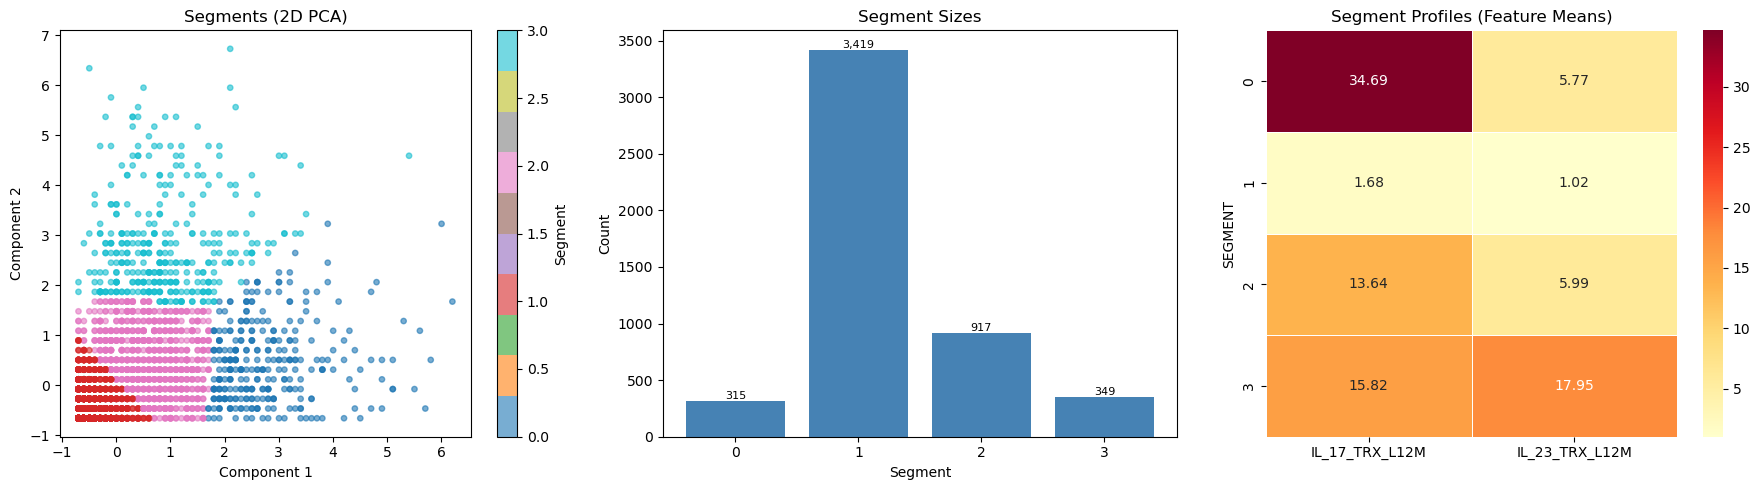

In [5]:
%matplotlib inline
# We pass a fresh pipeline because the per-instance state from .run() is what
# show_dashboard reads. Easier route: keep the original pipeline reference.
pipeline = SegmentationPipeline()
out = pipeline.run(cfg, dataframes={'entity_data': hcps})
pipeline.show_dashboard(out)

## What just happened

| Step | What it did |
|---|---|
| `us_hcp.generate_all()` | Built a realistic HCP reference table in memory (no PII). |
| `SegmentationConfig(...)` | Declared which column is the entity ID and which are the features. The same config shape works for accounts, customers, anything. |
| `SegmentationPipeline().run(...)` | Normalised features, fitted KMeans, attached labels, computed silhouette, wrote a CSV. |

**Next:** [`01_one_template_three_regions.ipynb`](./01_one_template_three_regions.ipynb)
shows the same pipeline reused across US, EU, and BRIC schemas.